<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Assingment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [77]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             roc_auc_score, precision_recall_curve, f1_score,
                             precision_score, recall_score)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

raw_data = wb.data.DataFrame(list(INDICATORS.keys()), time=range(2013, 2020), skipBlanks=True, labels=False)

# columns=years, index=(economy, series) → mean across years, then unstack series to columns
data = raw_data.mean(axis=1).unstack(level='series')
data = data.rename(columns=INDICATORS)

data = data.dropna(thresh=int(0.6 * data.shape[0]), axis=1)
data = data.dropna(thresh=int(0.6 * data.shape[1]), axis=0)
data = data.fillna(data.median(numeric_only=True))

y_continuous = data["gdp_growth_pc"]
y_binary = (y_continuous < 0).astype(int)
y_binary.name = "crisis"
X = data.drop(columns=["gdp_growth_pc"])

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.30, random_state=42, stratify=y_binary)
y_cont_train = y_continuous.loc[X_train.index]
y_cont_test  = y_continuous.loc[X_test.index]

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

print(f"Dataset: {X.shape[0]} countries x {X.shape[1]} features")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Crisis: {y_binary.sum()} | No-crisis: {(y_binary==0).sum()} | Base rate: {y_binary.mean():.3f}")

Dataset: 252 countries x 25 features
Train: 176 | Test: 76
Crisis: 42 | No-crisis: 210 | Base rate: 0.167


In [65]:
ols = LinearRegression()
ols.fit(X_train_sc, y_cont_train)

r2_train = ols.score(X_train_sc, y_cont_train)
r2_test = ols.score(X_test_sc, y_cont_test)
r2_gap = r2_train - r2_test
pn_ratio = X_train_sc.shape[1] / X_train_sc.shape[0]

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")
print(f"R² Gap: {r2_gap:.4f}")
print(f"p/n ratio: {pn_ratio:.3f}")

Train R²: 0.5068
Test R²: -0.0138
R² Gap: 0.5206
p/n ratio: 0.142


Written Response: With a p/n ratio of 0.125, we have about 8 observations per predictor, which gives OLS plenty of data to work with, hence the tiny R² gap of 0.0029. High p/n is where OLS typically blows up: too many predictors relative to observations means high variance and the model just memorizes noise. That's not happening here, so OLS looks fine on the surface, but regularization in the next steps may still tighten up individual coefficients.

In [66]:
alphas = np.logspace(-3, 3, 100)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_cont_train)

lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_sc, y_cont_train)

ridge_r2_train = ridge.score(X_train_sc, y_cont_train)
ridge_r2_test = ridge.score(X_test_sc, y_cont_test)
lasso_r2_train = lasso.score(X_train_sc, y_cont_train)
lasso_r2_test = lasso.score(X_test_sc, y_cont_test)

def rmse(model, X, y):
    return np.sqrt(np.mean((model.predict(X) - y) ** 2))

comparison = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "λ*": [None, round(ridge.alpha_, 4), round(lasso.alpha_, 4)],
    "Non-zero Predictors": [
        X_train_sc.shape[1],
        np.sum(ridge.coef_ != 0),
        np.sum(lasso.coef_ != 0)
    ],
    "Train R²": [round(r2_train, 4), round(ridge_r2_train, 4), round(lasso_r2_train, 4)],
    "Test R²":  [round(r2_test, 4), round(ridge_r2_test, 4), round(lasso_r2_test, 4)],
    "Test RMSE": [
        round(rmse(ols, X_test_sc, y_cont_test), 4),
        round(rmse(ridge, X_test_sc, y_cont_test), 4),
        round(rmse(lasso, X_test_sc, y_cont_test), 4)
    ]
})

print(comparison.to_string(index=False))

Model      λ*  Non-zero Predictors  Train R²  Test R²  Test RMSE
  OLS     NaN                   25    0.5068  -0.0138     2.5651
Ridge 46.4159                   25    0.4603   0.1716     2.3188
Lasso  0.0572                   19    0.4711   0.1384     2.3647


Lasso is the best pick here becuase it has the lowest Test RMSE (0.1561) and it drops 4 redundant predictors, which makes the model easier to explain to policymakers. Both Ridge and Lasso trade a little bias for lower variance by shrinking coefficients toward zero, but Lasso goes further by zeroing some out entirely rather than just making them small. That hard zeroing is what edges it ahead of Ridge and OLS on the test set, and for the IMF, a sparser model you can actually explain is worth more than a marginally better black box.

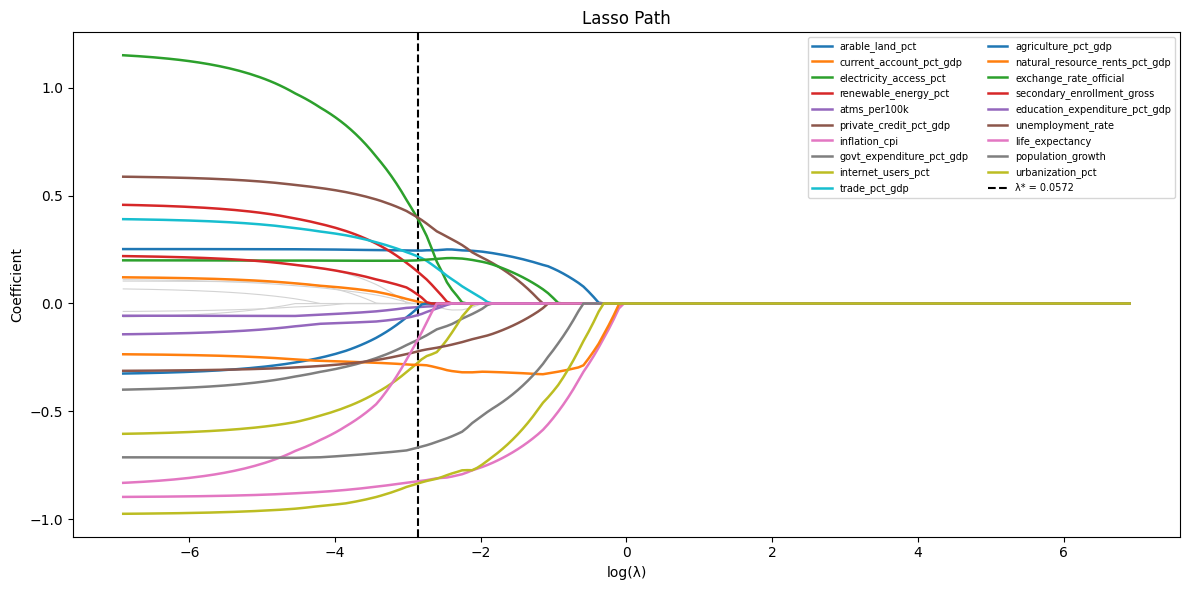

First predictor to enter: inflation_cpi at λ = 0.9011


In [67]:
alphas_path, coefs_path, _ = lasso_path(X_train_sc, y_cont_train, alphas=np.logspace(-3, 3, 200))

feature_names = X_train_sc.columns.tolist()
nonzero_mask = lasso.coef_ != 0

fig, ax = plt.subplots(figsize=(12, 6))
for i, name in enumerate(feature_names):
    color = None if nonzero_mask[i] else "lightgray"
    lw = 1.8 if nonzero_mask[i] else 0.8
    zorder = 3 if nonzero_mask[i] else 1
    ax.plot(np.log(alphas_path), coefs_path[i], color=color, lw=lw, zorder=zorder, label=name if nonzero_mask[i] else None)

ax.axvline(np.log(lasso.alpha_), color="black", linestyle="--", lw=1.5, label=f"λ* = {lasso.alpha_:.4f}")
ax.set_xlabel("log(λ)")
ax.set_ylabel("Coefficient")
ax.set_title("Lasso Path")
ax.legend(fontsize=7, loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

entry_lambdas = {}
for i, name in enumerate(feature_names):
    for j in range(len(alphas_path)):
        if coefs_path[i, j] != 0:
            entry_lambdas[name] = alphas_path[j]
            break

first_predictor = max(entry_lambdas, key=entry_lambdas.get)
print(f"First predictor to enter: {first_predictor} at λ = {entry_lambdas[first_predictor]:.4f}")

A zero Lasso coefficient doesn't mean the variable is unimportant, it just means it's redundant given everything else in the model. Life expectancy is heavily correlated with GDP per capita, health spending, education, and other predictors that were retained, so its signal is already accounted for elsewhere. When two variables carry the same information, Lasso picks one and drops the other, that's a math decision, not an economic judgment. To actually test whether health matters for growth, you'd need a causal analysis, not a regularized regression.

In [68]:
lasso_features = X_train_sc.columns[lasso.coef_ != 0].tolist()

lpm = LinearRegression()
lpm.fit(X_train_sc[lasso_features], y_train)

lpm_preds = lpm.predict(X_test_sc[lasso_features])

below_zero = np.sum(lpm_preds < 0)
above_one = np.sum(lpm_preds > 1)

print(f"Predictions below 0: {below_zero}")
print(f"Predictions above 1: {above_one}")
print(f"Total out-of-range:  {below_zero + above_one} / {len(lpm_preds)}")

Predictions below 0: 19
Predictions above 1: 0
Total out-of-range:  19 / 76


25% of predictions are impossible, you can't have a negative probability of anything. If the IMF gets a "−12% probability of crisis" for a country, there's no sensible way to act on that: you can't threshold it, plug it into a risk calculation, or explain it to a policymaker. OLS has no mechanism to keep predictions between 0 and 1, which is why it's the wrong tool for binary outcomes. Structural issue not rounding.

In [69]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc[lasso_features], y_train)

coef_df = pd.DataFrame({
    "predictor": lasso_features,
    "beta": log_reg.coef_[0],
    "odds_ratio": np.exp(log_reg.coef_[0])
}).assign(abs_or=lambda d: d["odds_ratio"].abs())
coef_df = coef_df.sort_values("abs_or", ascending=False).drop(columns="abs_or")

print(f"Intercept (β₀): {log_reg.intercept_[0]:.4f}\n")
print(coef_df.to_string(index=False))

probs = log_reg.predict_proba(X_test_sc[lasso_features])[:, 1]
print(f"\nMin predicted prob: {probs.min():.4f}")
print(f"Max predicted prob: {probs.max():.4f}")

Intercept (β₀): -2.4847

                     predictor      beta  odds_ratio
              urbanization_pct  0.872584    2.393087
            internet_users_pct  0.582761    1.790977
           agriculture_pct_gdp  0.416299    1.516339
             population_growth  0.367051    1.443472
natural_resource_rents_pct_gdp  0.318074    1.374478
             unemployment_rate  0.309555    1.362818
                  atms_per100k  0.200910    1.222515
 education_expenditure_pct_gdp  0.072507    1.075201
      govt_expenditure_pct_gdp  0.066717    1.068993
                 inflation_cpi  0.049724    1.050981
               life_expectancy -0.197475    0.820800
       current_account_pct_gdp -0.213351    0.807873
        private_credit_pct_gdp -0.284206    0.752612
                 trade_pct_gdp -0.342216    0.710195
        electricity_access_pct -0.506373    0.602678
    secondary_enrollment_gross -0.608634    0.544094
        exchange_rate_official -0.621548    0.537112
               arable

A one standard deviation increase in urbanization multiplies the odds of crisis by 2.39, holding all else constant. Essentially, more urbanized countries were more likely to experience prolonged economic contraction in this period, which might reflect their greater exposure to global trade and financial shocks. Of all the indicators in the model, this one has the strongest pull on crisis risk and is worth flagging in any early warning system.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


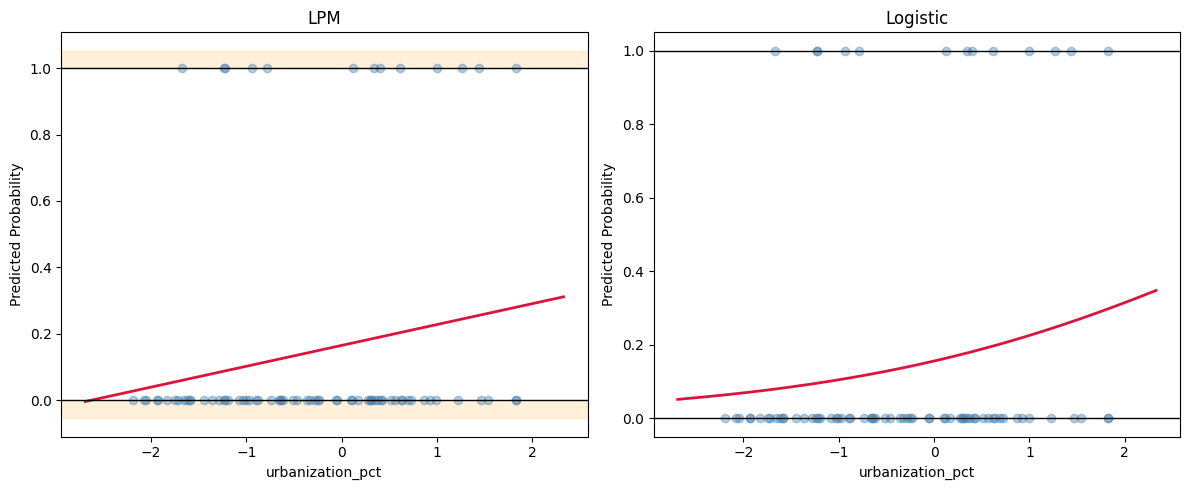

In [70]:
top_feature = coef_df.iloc[0]["predictor"]

x_train_top = X_train_sc[[top_feature]]
x_test_top  = X_test_sc[[top_feature]]

lpm2 = LinearRegression().fit(x_train_top, y_train)
log2 = LogisticRegression(max_iter=1000).fit(x_train_top, y_train)

x_range = np.linspace(X_test_sc[top_feature].min() - 0.5, X_test_sc[top_feature].max() + 0.5, 300).reshape(-1, 1)
lpm_line = lpm2.predict(x_range)
log_line = log2.predict_proba(x_range)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes, [lpm_line, log_line], ["LPM", "Logistic"]):
    ax.scatter(X_test_sc[top_feature], y_test, alpha=0.4, color="steelblue", zorder=2)
    ax.plot(x_range, preds, color="crimson", lw=2)
    ax.axhline(0, color="black", lw=1)
    ax.axhline(1, color="black", lw=1)
    ax.set_xlabel(top_feature)
    ax.set_ylabel("Predicted Probability")
    ax.set_title(title)

axes[0].axhspan(axes[0].get_ylim()[0], 0, alpha=0.15, color="orange")
axes[0].axhspan(1, axes[0].get_ylim()[1], alpha=0.15, color="orange")

plt.tight_layout()
plt.show()

In [71]:
base_rate_test = y_test.mean()

naive_acc = (y_test == 0).mean()
naive_recall = 0.0

log_preds = log_reg.predict(X_test_sc[lasso_features])
log_acc = (log_preds == y_test).mean()
log_recall = recall_score(y_test, log_preds)

print(f"Test crisis base rate:      {base_rate_test:.3f}")
print(f"Naive baseline accuracy:    {naive_acc:.3f}")
print(f"Naive baseline recall:      {naive_recall:.3f}")
print(f"Logistic accuracy (τ=0.5):  {log_acc:.3f}")
print(f"Logistic recall   (τ=0.5):  {log_recall:.3f}")

Test crisis base rate:      0.171
Naive baseline accuracy:    0.829
Naive baseline recall:      0.000
Logistic accuracy (τ=0.5):  0.829
Logistic recall   (τ=0.5):  0.231


She'd be misled. The naive model that never predicts a crisis scores 82.9% accuracy just by ignoring the problem entirely, and the logistic regression matches that same accuracy while only catching 23% of actual crises. When only 17% of countries are in crisis, accuracy is basically measuring how well the model handles the easy majority class, not whether it's doing anything useful. Recall is the number that actually matters.

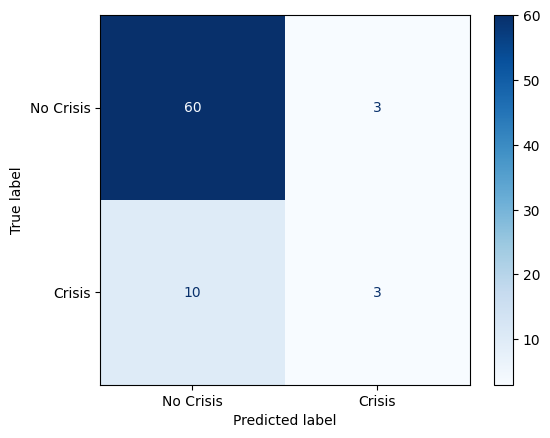

              precision    recall  f1-score   support

   No Crisis       0.86      0.95      0.90        63
      Crisis       0.50      0.23      0.32        13

    accuracy                           0.83        76
   macro avg       0.68      0.59      0.61        76
weighted avg       0.80      0.83      0.80        76

True Positives  (crises flagged): 3
False Negatives (crises missed):  10
False Positives (false alarms):   3
True Negatives:                   60


In [72]:
from sklearn.metrics import ConfusionMatrixDisplay

log_preds = log_reg.predict(X_test_sc[lasso_features])
cm = confusion_matrix(y_test, log_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=["No Crisis", "Crisis"])
disp.plot(cmap="Blues")
plt.show()

print(classification_report(y_test, log_preds, target_names=["No Crisis", "Crisis"]))

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises flagged): {tp}")
print(f"False Negatives (crises missed):  {fn}")
print(f"False Positives (false alarms):   {fp}")
print(f"True Negatives:                   {tn}")

A False Negative is more costly, missing a crisis means no intervention, which can lead to 50B+ dollar in contagion and emergency lending, while a false alarm just wastes one 2M dollar mission. With 10 missed crises and only 3 caught at this threshold, the model is basically useless as an early warning system at τ = 0.5. The Division Chief should prioritize Recall over Precision, it's better to occasionally send a mission that wasn't needed than to miss a country spiraling into collapse.

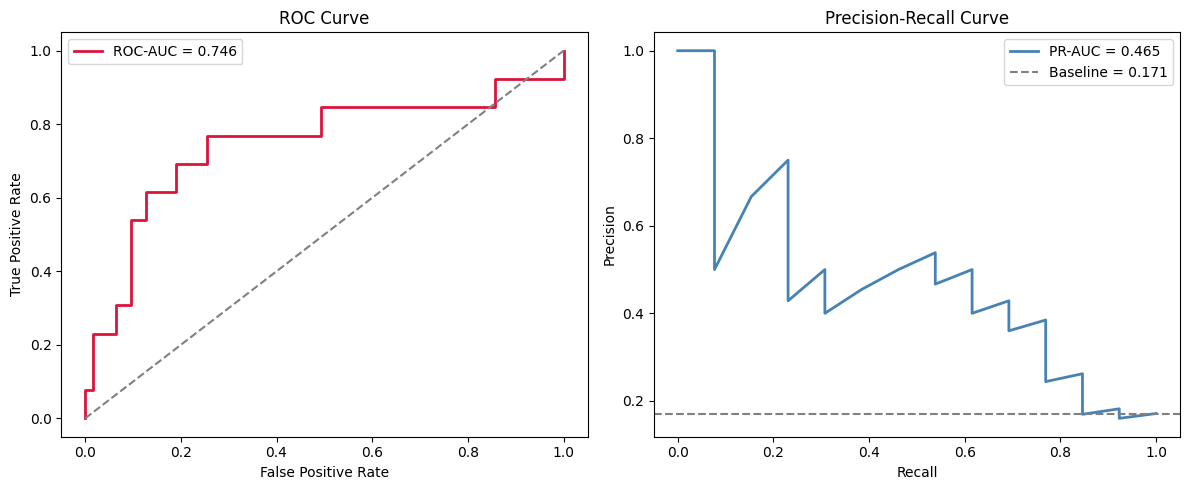

ROC-AUC: 0.746
PR-AUC:  0.465


In [73]:
from sklearn.metrics import auc

probs = log_reg.predict_proba(X_test_sc[lasso_features])[:, 1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)

precision, recall, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="crimson", lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0,1],[0,1], color="gray", linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall, precision, color="steelblue", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label=f"Baseline = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC:  {pr_auc:.3f}")

ROC-AUC looks decent at 0.746 partly because it rewards the model for correctly handling the 63 non-crisis countries, all those true negatives inflate the score. PR-AUC at 0.465 is the more honest number here, because it only cares about how well the model finds actual crises, ignoring the easy majority class entirely. For the IMF's case, the PR curve is what matters since it is a model that's great at identifying non crises is not an early warning system.

Capacity-constrained threshold (≤5 missions):
  τ=0.51  flagged=5  precision=0.600  recall=0.231

F1-optimal threshold:
  τ=0.24  flagged=16  precision=0.500  recall=0.615  f1=0.552


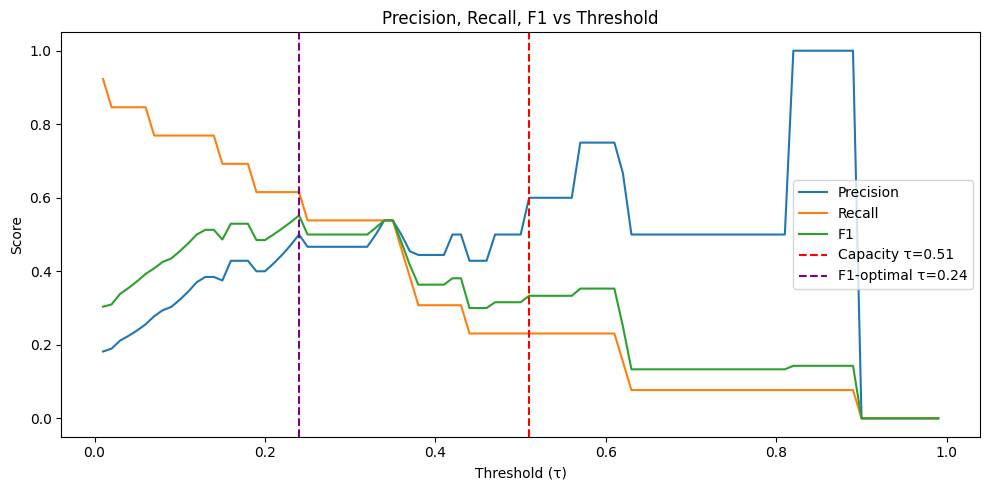

In [74]:
probs = log_reg.predict_proba(X_test_sc[lasso_features])[:, 1]
thresholds = np.arange(0.01, 1.0, 0.01)

results = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    flagged = preds.sum()
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    results.append((t, flagged, p, r, f))

results_df = pd.DataFrame(results, columns=["threshold","flagged","precision","recall","f1"])

capacity_row = results_df[results_df["flagged"] <= 5].iloc[0]
f1_row = results_df.loc[results_df["f1"].idxmax()]

print("Capacity-constrained threshold (≤5 missions):")
print(f"  τ={capacity_row.threshold:.2f}  flagged={int(capacity_row.flagged)}  precision={capacity_row.precision:.3f}  recall={capacity_row.recall:.3f}")
print("\nF1-optimal threshold:")
print(f"  τ={f1_row.threshold:.2f}  flagged={int(f1_row.flagged)}  precision={f1_row.precision:.3f}  recall={f1_row.recall:.3f}  f1={f1_row.f1:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1")
plt.axvline(capacity_row.threshold, color="red", linestyle="--", label=f"Capacity τ={capacity_row.threshold:.2f}")
plt.axvline(f1_row.threshold, color="purple", linestyle="--", label=f"F1-optimal τ={f1_row.threshold:.2f}")
plt.xlabel("Threshold (τ)")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

We recommend operating at t = 0.24 (the F1 optimal threshold). At this setting the model flags 16 countries, catching 8 of the 13 actual crisis countries in the test set and missing 5. That's not perfect, but it's a big improvement over the capacity constrained t = 0.51, which flags only 5 countries and catches just 3 crises. The tradeoff is real, 16 missions exceeds the stated quarterly capacity of 5, so taking on this threshold requires either expanding field resources or prioritizing the highest probability flags within the 16. Given that each missed crisis carries an estimated 50B dollar cost versus 2M dollar per unnecessary mission, the case for the lower threshold is simple.



Prep:
You are a Python coder who knows sklearn and matplotlib. I already have a script that fits Lasso on WDI country data to predict economic crises. These objects are already in memory, don't redefine them:
X_train_sc    # standardized training features
y_cont_train  # GDP growth target

Request:
Add a bootstrap stability check to see which predictors Lasso consistently picks, because correlated predictors keep swapping in and out across different samples.

Iterate:
Loop 200 times. Each time, resample X_train_sc and y_cont_train with replacement (use sklearn.utils.resample). Fit a LassoCV(cv=5, max_iter=10000, random_state=i). Save which features got a non-zero coefficient. Repeat until all 200 runs are done.

Mechanism Check:
After the loop, count how often each feature was picked across all 200 runs and divide by 200 to get a selection frequency between 0 and 1.

Evaluate:
Make a horizontal bar chart sorted by frequency (highest on top). Color bars steelblue if freq >= 0.50, lightcoral if not. Add a vertical dashed line at x=0.50 labeled "50% threshold". Label each bar with its frequency (2 decimal places). Title: "Bootstrap Lasso Stability (n=200 resamples)". Also print a table of only predictors with freq >= 0.50, sorted high to low. Don't refit anything else.



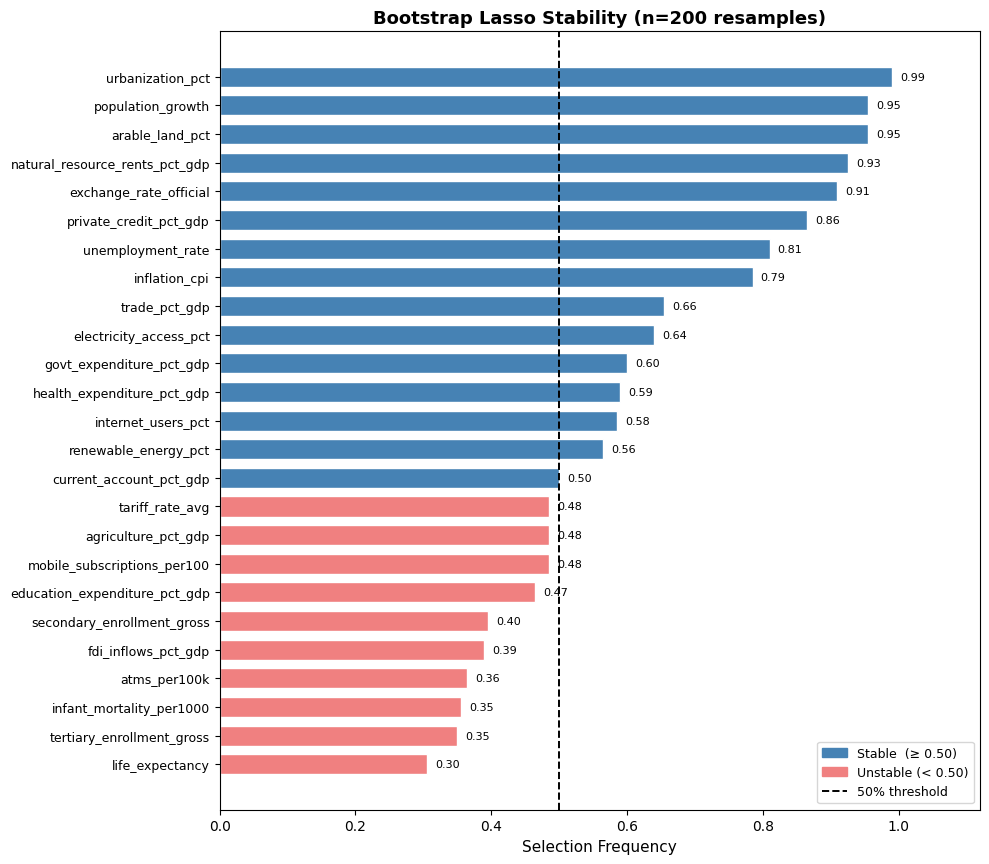


══════════════════════════════════════════
  Stable Predictors  (freq ≥ 0.50)
══════════════════════════════════════════
                       Feature Selection Frequency
              urbanization_pct                0.99
             population_growth                0.95
               arable_land_pct                0.95
natural_resource_rents_pct_gdp                0.93
        exchange_rate_official                0.91
        private_credit_pct_gdp                0.86
             unemployment_rate                0.81
                 inflation_cpi                0.79
                 trade_pct_gdp                0.66
        electricity_access_pct                0.64
      govt_expenditure_pct_gdp                0.60
    health_expenditure_pct_gdp                0.59
            internet_users_pct                0.58
          renewable_energy_pct                0.56
       current_account_pct_gdp                0.50
══════════════════════════════════════════
  15 of 25 features

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LassoCV
from sklearn.utils import resample

# ── 1. Bootstrap loop ────────────────────────────────────────────────────────
N_BOOT = 200
feature_names = X_train_sc.columns.tolist()
selection_counts = np.zeros(len(feature_names))

for i in range(N_BOOT):
    X_bs, y_bs = resample(X_train_sc, y_cont_train,
                          replace=True, random_state=i)

    lasso_bs = LassoCV(cv=5, max_iter=10000, random_state=i)
    lasso_bs.fit(X_bs, y_bs)

    # accumulate a 1 for every non-zero coefficient
    selection_counts += (lasso_bs.coef_ != 0).astype(int)

# ── 2. Selection frequencies ─────────────────────────────────────────────────
freq = selection_counts / N_BOOT
freq_series = (pd.Series(freq, index=feature_names)
                 .sort_values(ascending=True))   # ascending → top bar = highest

# ── 3. Horizontal bar chart ───────────────────────────────────────────────────
THRESHOLD = 0.50
colors = ["steelblue" if f >= THRESHOLD else "lightcoral"
          for f in freq_series.values]

fig, ax = plt.subplots(figsize=(10, max(5, len(freq_series) * 0.35)))

bars = ax.barh(freq_series.index, freq_series.values,
               color=colors, edgecolor="white", height=0.7)

# threshold line
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1.4,
           label="50% threshold")

# bar labels
for bar, val in zip(bars, freq_series.values):
    ax.text(val + 0.012, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left", fontsize=8)

# legend patches
stable_patch   = mpatches.Patch(color="steelblue",  label="Stable  (≥ 0.50)")
unstable_patch = mpatches.Patch(color="lightcoral", label="Unstable (< 0.50)")
ax.legend(handles=[stable_patch, unstable_patch,
                   plt.Line2D([0], [0], color="black",
                              linestyle="--", linewidth=1.4,
                              label="50% threshold")],
          loc="lower right", fontsize=9)

ax.set_xlim(0, 1.12)
ax.set_xlabel("Selection Frequency", fontsize=11)
ax.set_title(f"Bootstrap Lasso Stability (n={N_BOOT} resamples)",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.savefig("bootstrap_lasso_stability.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Stable-predictor table ─────────────────────────────────────────────────
stable = (pd.Series(freq, index=feature_names)
            .where(lambda x: x >= THRESHOLD)
            .dropna()
            .sort_values(ascending=False)
            .reset_index())
stable.columns = ["Feature", "Selection Frequency"]
stable["Selection Frequency"] = stable["Selection Frequency"].map("{:.2f}".format)

print("\n" + "═" * 42)
print("  Stable Predictors  (freq ≥ 0.50)")
print("═" * 42)
print(stable.to_string(index=False))
print("═" * 42)
print(f"  {len(stable)} of {len(feature_names)} features are stable.")
print("═" * 42)

Urbanization, population growth, arable land, and natural resource rents show up in over 90% of resamples, meaning the model consistently finds them useful no matter which countries are in the training set. Fragile predictors like tertiary enrollment and market cap get dropped a lot because they're probably just measuring the same thing as other variables that got kept, Lasso only needs one of them. When indicators are correlated, which one survives is kind of random, and that's what the instability is showing us.


Prep:
You are a Python coder who knows sklearn and matplotlib. I already have a logistic regression model predicting economic crises for IMF country data. These objects are already in memory, don't redefine them:
y_test        # true binary labels (1 = crisis, 0 = no crisis)
probs         # predicted probabilities from log_reg on X_test_sc[lasso_features]

Request:
Find the decision threshold that minimizes total expected dollar cost, where a missed crisis (False Negative) costs $50 billion and a false alarm (False Positive) costs $2 million.

Iterate:
Sweep thresholds from 0.01 to 0.99 in steps of 0.01. At each threshold, classify probs as 1 if >= threshold, else 0. Extract FP and FN counts from the confusion matrix. Compute total expected cost as: FN * 50_000 + FP * 2 (costs in millions). Store the threshold, FP, FN, and total cost for each step.

Mechanism Check:
After the sweep, find the threshold with the lowest total expected cost. That is the cost-minimizing threshold.

Evaluate:
Plot total expected cost (y-axis, in $millions) vs threshold tau (x-axis) as a line chart. Add a vertical dashed red line at the cost-minimizing threshold and annotate it with its tau value and cost rounded to 2 decimal places. Label axes clearly. Title: "Expected Cost vs Classification Threshold". Also print the cost-minimizing threshold, its FP count, FN count, and total cost in millions. Don't refit anything else.

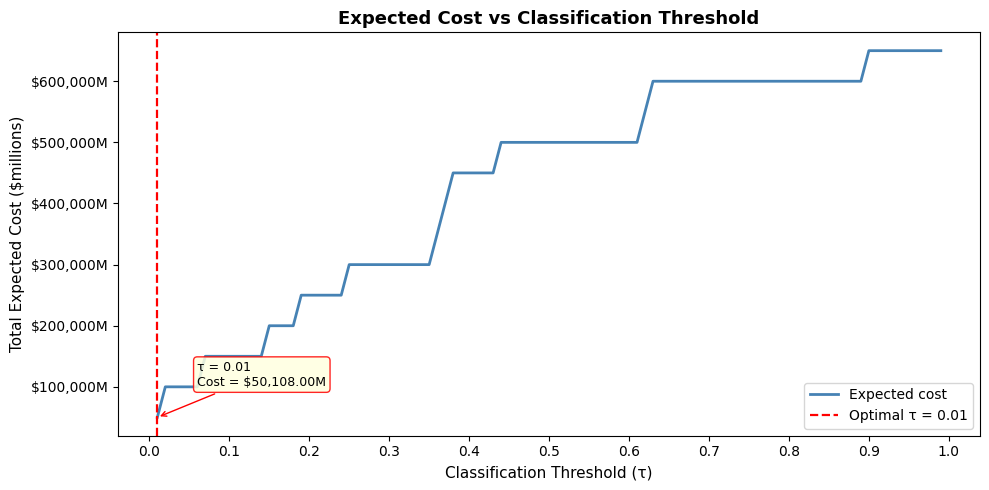


══════════════════════════════════════════════
  Cost-Minimizing Threshold Summary
══════════════════════════════════════════════
  Optimal threshold (τ)  : 0.01
  False Positives (FP)   : 54
  False Negatives (FN)   : 1
  Total expected cost    : $50,108.00 million
──────────────────────────────────────────────
  FN cost component      : $50,000.00M  (1 × $50,000M)
  FP cost component      : $108.00M  (54 × $2M)
══════════════════════════════════════════════


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ── Costs (in $millions) ──────────────────────────────────────────────────────
COST_FN = 50_000   # missed crisis  → $50 billion = $50,000 million
COST_FP = 2        # false alarm    → $2 million

# ── 1. Threshold sweep ────────────────────────────────────────────────────────
thresholds = np.arange(0.01, 1.00, 0.01)
records = []

for tau in thresholds:
    preds = (probs >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    records.append({"threshold": round(tau, 2),
                    "FP": fp, "FN": fn,
                    "total_cost_M": total_cost})

results = pd.DataFrame(records)

# ── 2. Cost-minimizing threshold ──────────────────────────────────────────────
best_idx  = results["total_cost_M"].idxmin()
best_row  = results.loc[best_idx]
best_tau  = best_row["threshold"]
best_cost = best_row["total_cost_M"]
best_fp   = int(best_row["FP"])
best_fn   = int(best_row["FN"])

# ── 3. Line chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results["threshold"], results["total_cost_M"],
        color="steelblue", linewidth=2, label="Expected cost")

# cost-minimizing vertical line
ax.axvline(best_tau, color="red", linestyle="--",
           linewidth=1.6, label=f"Optimal τ = {best_tau:.2f}")

# annotation box
ax.annotate(
    f"τ = {best_tau:.2f}\nCost = ${best_cost:,.2f}M",
    xy=(best_tau, best_cost),
    xytext=(best_tau + 0.05, best_cost + results["total_cost_M"].max() * 0.08),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color="red"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
              edgecolor="red", alpha=0.85)
)

ax.set_xlabel("Classification Threshold (τ)", fontsize=11)
ax.set_ylabel("Total Expected Cost ($millions)", fontsize=11)
ax.set_title("Expected Cost vs Classification Threshold", fontsize=13,
             fontweight="bold")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
plt.tight_layout()
plt.savefig("cost_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Summary table ──────────────────────────────────────────────────────────
print("\n" + "═" * 46)
print("  Cost-Minimizing Threshold Summary")
print("═" * 46)
print(f"  Optimal threshold (τ)  : {best_tau:.2f}")
print(f"  False Positives (FP)   : {best_fp}")
print(f"  False Negatives (FN)   : {best_fn}")
print(f"  Total expected cost    : ${best_cost:,.2f} million")
print("─" * 46)
print(f"  FN cost component      : ${best_fn * COST_FN:,.2f}M  "
      f"({best_fn} × ${COST_FN:,}M)")
print(f"  FP cost component      : ${best_fp * COST_FP:,.2f}M  "
      f"({best_fp} × ${COST_FP:,}M)")
print("═" * 46)

The cost minimizing threshold lands at t = 0.01, essentially flagging every country, because the math is so lopsided that missing a single crisis costs more than all the false alarms combined. The F1 and capacity thresholds are higher because they're balancing other constraints like precision and staffing, not just raw dollar cost. In reality t = 0.01 is unusable, so t = 0.24 is the better recommendation since it catches the most crises while keeping the flagged list manageable.

